# EDA — dados educacionais
Objetivo: entender como os dados de cada tabela estão distribuídos e visualizá-los através de gráficos

## Instalando bibliotecas

In [72]:
!pip install polars
!pip install matplotlib
!pip install seaborn

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached numpy-2.4.4-cp313-cp313-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached pillow-12.2.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (8.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 48.7 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 63.9 MB/s  0:00:00
Using cached numpy-2.4.4-cp313-cp313-macosx_14_0_arm64.whl (5.2 MB)
Using cached pillow-12.2.0-cp313-cp313-macosx_11_0_arm64.whl (4.7 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached pandas-3.0.2-cp313-cp313-macosx_11_0_arm64.whl.metadata (79 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached pandas-3.0.2-cp313-cp313-macosx_11_0_arm64.whl (9.9 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [seaborn]m1/2 [seaborn]


## Importando bibliotecas

In [73]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns


## Análise inicial das tabelas

### Tabela aluno

#### Análise
Total de registros: 97044 ; Total de registros duplicados: 0 ; Total de registros nulos: bairro (68)

In [103]:
df_aluno = pl.read_parquet("../data/aluno")
print("Colunas: ", df_aluno.columns)
print("Tipos de dados: ", df_aluno.dtypes)
print("Total de registros: ", df_aluno.shape[0])
print("Total de registros duplicados: ", df_aluno.is_duplicated().sum())
print("Total de registros nulos: ", df_aluno.null_count())


Colunas:  ['id_aluno', 'id_turma', 'faixa_etaria', 'bairro']
Tipos de dados:  [Binary, Int64, String, Int64]
Total de registros:  97044
Total de registros duplicados:  0
Total de registros nulos:  shape: (1, 4)
┌──────────┬──────────┬──────────────┬────────┐
│ id_aluno ┆ id_turma ┆ faixa_etaria ┆ bairro │
│ ---      ┆ ---      ┆ ---          ┆ ---    │
│ u32      ┆ u32      ┆ u32          ┆ u32    │
╞══════════╪══════════╪══════════════╪════════╡
│ 0        ┆ 0        ┆ 0            ┆ 68     │
└──────────┴──────────┴──────────────┴────────┘


#### Tratamentos
Após verificar que existem 68 registros nulos (que não representa nem 0,1% dos dados), considerei removê-los por acreditar que não terá impacto nos passos seguintes

In [111]:
df_aluno = df_aluno.drop_nulls()
print("Total de registros: ", df_aluno.shape[0])
print("Total de registros nulos: ", df_aluno.null_count())

Total de registros:  96976
Total de registros nulos:  shape: (1, 4)
┌──────────┬──────────┬──────────────┬────────┐
│ id_aluno ┆ id_turma ┆ faixa_etaria ┆ bairro │
│ ---      ┆ ---      ┆ ---          ┆ ---    │
│ u32      ┆ u32      ┆ u32          ┆ u32    │
╞══════════╪══════════╪══════════════╪════════╡
│ 0        ┆ 0        ┆ 0            ┆ 0      │
└──────────┴──────────┴──────────────┴────────┘


#### Análise após tratamento
Total de registros:  96976

Total de registros duplicados:  0

### Tabela avaliacao

#### Análise
Total de registros: 221687

Total de registros duplicados: 6 

Total de registros nulos: frequencia (1734), disciplina_1 (34609), disciplina_2 (35931), disciplina_3 (221687), disciplina_4 (35462)

In [166]:
df_avaliacao = pl.read_parquet("../data/avaliacao")
print("Colunas: ", df_avaliacao.columns)
print("Tipos de dados: ", df_avaliacao.dtypes)
print("Total de registros: ", df_avaliacao.shape[0])
print("Total de registros duplicados: ", df_avaliacao.is_duplicated().sum())
print("Total de registros nulos: ", df_avaliacao.null_count())

Colunas:  ['id_aluno', 'id_turma', 'frequencia', 'bimestre', 'disciplina_1', 'disciplina_2', 'disciplina_3', 'disciplina_4']
Tipos de dados:  [Binary, Int64, Float64, String, Float64, Float64, Float64, Float64]
Total de registros:  221687
Total de registros duplicados:  6
Total de registros nulos:  shape: (1, 8)
┌──────────┬──────────┬────────────┬──────────┬─────────────┬────────────┬────────────┬────────────┐
│ id_aluno ┆ id_turma ┆ frequencia ┆ bimestre ┆ disciplina_ ┆ disciplina ┆ disciplina ┆ disciplina │
│ ---      ┆ ---      ┆ ---        ┆ ---      ┆ 1           ┆ _2         ┆ _3         ┆ _4         │
│ u32      ┆ u32      ┆ u32        ┆ u32      ┆ ---         ┆ ---        ┆ ---        ┆ ---        │
│          ┆          ┆            ┆          ┆ u32         ┆ u32        ┆ u32        ┆ u32        │
╞══════════╪══════════╪════════════╪══════════╪═════════════╪════════════╪════════════╪════════════╡
│ 0        ┆ 0        ┆ 1734       ┆ 0        ┆ 34609       ┆ 35931      ┆ 22168

#### Tratamento 1
Após verificar que existem 6 registros duplicados (que não representa nem 0,1% dos dados), considerei removê-los por acreditar que não terá impacto nos passos seguintes

In [167]:
df_avaliacao = df_avaliacao.unique(maintain_order=True)
print("Total de registros: ", df_avaliacao.shape[0])
print("Total de registros duplicados: ", df_avaliacao.is_duplicated().sum())
print("Total de registros nulos: ", df_avaliacao.null_count())

Total de registros:  221684
Total de registros duplicados:  0
Total de registros nulos:  shape: (1, 8)
┌──────────┬──────────┬────────────┬──────────┬─────────────┬────────────┬────────────┬────────────┐
│ id_aluno ┆ id_turma ┆ frequencia ┆ bimestre ┆ disciplina_ ┆ disciplina ┆ disciplina ┆ disciplina │
│ ---      ┆ ---      ┆ ---        ┆ ---      ┆ 1           ┆ _2         ┆ _3         ┆ _4         │
│ u32      ┆ u32      ┆ u32        ┆ u32      ┆ ---         ┆ ---        ┆ ---        ┆ ---        │
│          ┆          ┆            ┆          ┆ u32         ┆ u32        ┆ u32        ┆ u32        │
╞══════════╪══════════╪════════════╪══════════╪═════════════╪════════════╪════════════╪════════════╡
│ 0        ┆ 0        ┆ 1734       ┆ 0        ┆ 34606       ┆ 35928      ┆ 221684     ┆ 35459      │
└──────────┴──────────┴────────────┴──────────┴─────────────┴────────────┴────────────┴────────────┘


#### Tratamento 2
Após verificar que 100% dos registros da coluna disciplina_3 são nulos, considerei removê-los por acreditar que não terá impacto nos passos seguintes

In [168]:
df_avaliacao = df_avaliacao.drop("disciplina_3")
print("Total de registros: ", df_avaliacao.shape[0])
print("Total de registros nulos: ", df_avaliacao.null_count())

Total de registros:  221684
Total de registros nulos:  shape: (1, 7)
┌──────────┬──────────┬────────────┬──────────┬──────────────┬──────────────┬──────────────┐
│ id_aluno ┆ id_turma ┆ frequencia ┆ bimestre ┆ disciplina_1 ┆ disciplina_2 ┆ disciplina_4 │
│ ---      ┆ ---      ┆ ---        ┆ ---      ┆ ---          ┆ ---          ┆ ---          │
│ u32      ┆ u32      ┆ u32        ┆ u32      ┆ u32          ┆ u32          ┆ u32          │
╞══════════╪══════════╪════════════╪══════════╪══════════════╪══════════════╪══════════════╡
│ 0        ┆ 0        ┆ 1734       ┆ 0        ┆ 34606        ┆ 35928        ┆ 35459        │
└──────────┴──────────┴────────────┴──────────┴──────────────┴──────────────┴──────────────┘


#### Tratamento 3
Após verificar que 15,6% dos registros da coluna disciplina_1 são nulos, considerei substituí-los pela mediana das frequências

In [169]:
df_avaliacao = df_avaliacao.with_columns(
    pl.when(pl.col("disciplina_1").is_null())
    .then(pl.col("disciplina_1").median())
    .otherwise(pl.col("disciplina_1"))
)
print("Total de registros nulos: ", df_avaliacao.null_count())

Total de registros nulos:  shape: (1, 7)
┌──────────┬──────────┬────────────┬──────────┬──────────────┬──────────────┬──────────────┐
│ id_aluno ┆ id_turma ┆ frequencia ┆ bimestre ┆ disciplina_1 ┆ disciplina_2 ┆ disciplina_4 │
│ ---      ┆ ---      ┆ ---        ┆ ---      ┆ ---          ┆ ---          ┆ ---          │
│ u32      ┆ u32      ┆ u32        ┆ u32      ┆ u32          ┆ u32          ┆ u32          │
╞══════════╪══════════╪════════════╪══════════╪══════════════╪══════════════╪══════════════╡
│ 0        ┆ 0        ┆ 1734       ┆ 0        ┆ 0            ┆ 35928        ┆ 35459        │
└──────────┴──────────┴────────────┴──────────┴──────────────┴──────────────┴──────────────┘


#### Tratamento 4
Após verificar que 16,2% dos registros da coluna disciplina_2 são nulos, considerei substituí-los pela mediana das frequências

In [170]:
df_avaliacao = df_avaliacao.with_columns(
    pl.when(pl.col("disciplina_2").is_null())
    .then(pl.col("disciplina_2").median())
    .otherwise(pl.col("disciplina_2"))
)
print("Total de registros nulos: ", df_avaliacao.null_count())

Total de registros nulos:  shape: (1, 7)
┌──────────┬──────────┬────────────┬──────────┬──────────────┬──────────────┬──────────────┐
│ id_aluno ┆ id_turma ┆ frequencia ┆ bimestre ┆ disciplina_1 ┆ disciplina_2 ┆ disciplina_4 │
│ ---      ┆ ---      ┆ ---        ┆ ---      ┆ ---          ┆ ---          ┆ ---          │
│ u32      ┆ u32      ┆ u32        ┆ u32      ┆ u32          ┆ u32          ┆ u32          │
╞══════════╪══════════╪════════════╪══════════╪══════════════╪══════════════╪══════════════╡
│ 0        ┆ 0        ┆ 1734       ┆ 0        ┆ 0            ┆ 0            ┆ 35459        │
└──────────┴──────────┴────────────┴──────────┴──────────────┴──────────────┴──────────────┘


#### Tratamento 5
Após verificar que 15,9% dos registros da coluna disciplina_4 são nulos, considerei substituí-los pela mediana das frequências

In [171]:
df_avaliacao = df_avaliacao.with_columns(
    pl.when(pl.col("disciplina_4").is_null())
    .then(pl.col("disciplina_4").median())
    .otherwise(pl.col("disciplina_4"))
)
print("Total de registros nulos: ", df_avaliacao.null_count())

Total de registros nulos:  shape: (1, 7)
┌──────────┬──────────┬────────────┬──────────┬──────────────┬──────────────┬──────────────┐
│ id_aluno ┆ id_turma ┆ frequencia ┆ bimestre ┆ disciplina_1 ┆ disciplina_2 ┆ disciplina_4 │
│ ---      ┆ ---      ┆ ---        ┆ ---      ┆ ---          ┆ ---          ┆ ---          │
│ u32      ┆ u32      ┆ u32        ┆ u32      ┆ u32          ┆ u32          ┆ u32          │
╞══════════╪══════════╪════════════╪══════════╪══════════════╪══════════════╪══════════════╡
│ 0        ┆ 0        ┆ 1734       ┆ 0        ┆ 0            ┆ 0            ┆ 0            │
└──────────┴──────────┴────────────┴──────────┴──────────────┴──────────────┴──────────────┘


#### Tratamento 6
Após verificar que 0,7% dos registros da coluna disciplina_4 são nulos, considerei substituí-los pela mediana das frequências. Apesar de ser um % muito baixo, faz sentido substituir os valores.

In [172]:
df_avaliacao = df_avaliacao.with_columns(
    pl.when(pl.col("frequencia").is_null())
    .then(pl.col("frequencia").median())
    .otherwise(pl.col("frequencia"))
)
print("Total de registros nulos: ", df_avaliacao.null_count())

Total de registros nulos:  shape: (1, 7)
┌──────────┬──────────┬────────────┬──────────┬──────────────┬──────────────┬──────────────┐
│ id_aluno ┆ id_turma ┆ frequencia ┆ bimestre ┆ disciplina_1 ┆ disciplina_2 ┆ disciplina_4 │
│ ---      ┆ ---      ┆ ---        ┆ ---      ┆ ---          ┆ ---          ┆ ---          │
│ u32      ┆ u32      ┆ u32        ┆ u32      ┆ u32          ┆ u32          ┆ u32          │
╞══════════╪══════════╪════════════╪══════════╪══════════════╪══════════════╪══════════════╡
│ 0        ┆ 0        ┆ 0          ┆ 0        ┆ 0            ┆ 0            ┆ 0            │
└──────────┴──────────┴────────────┴──────────┴──────────────┴──────────────┴──────────────┘


#### Tratamento 7
Após verificar que a disciplina_1 representa Língua Portuguesa, que a disciplina_2 representa Matemática e que a disciplina_4 representa Ciências, considerei renomeá-las para facilitar análises futuras.

In [174]:
df_avaliacao = df_avaliacao.rename(
    {
        "disciplina_1": "lingua_portuguesa",
        "disciplina_2": "matematica",
        "disciplina_4": "ciencias",
    }
)
print("Colunas: ", df_avaliacao.columns)

Colunas:  ['id_aluno', 'id_turma', 'frequencia', 'bimestre', 'lingua_portuguesa', 'matematica', 'ciencias']


### Tabela escola

#### Análise
Total de registros: 1558 ; Total de registros duplicados: 0 ; Total de registros nulos: 0

In [96]:
df_escola = pl.read_parquet("../data/escola")
print("Colunas: ", df_escola.columns)
print("Tipos de dados: ", df_escola.dtypes)
print("Total de registros: ", df_escola.shape[0])
print("Total de registros duplicados: ", df_escola.is_duplicated().sum())
print("Total de registros nulos: ", df_escola.null_count())

Colunas:  ['id_escola', 'bairro']
Tipos de dados:  [Int64, Int64]
Total de registros:  1558
Total de registros duplicados:  0
Total de registros nulos:  shape: (1, 2)
┌───────────┬────────┐
│ id_escola ┆ bairro │
│ ---       ┆ ---    │
│ u32       ┆ u32    │
╞═══════════╪════════╡
│ 0         ┆ 0      │
└───────────┴────────┘


### Tabela frequencia

#### Análise
Total de registros: 2727684 ; Total de registros duplicados: 2952 ; Total de registros nulos: 0

In [109]:
df_frequencia = pl.read_parquet("../data/frequencia")
print("Colunas: ", df_frequencia.columns)
print("Tipos de dados: ", df_frequencia.dtypes)
print("Total de registros: ", df_frequencia.shape[0])
print("Total de registros duplicados: ", df_frequencia.is_duplicated().sum())
print("Total de registros nulos: ", df_frequencia.null_count())

Colunas:  ['id_escola', 'id_aluno', 'id_turma', 'data_inicio', 'data_fim', 'disciplina', 'frequencia']
Tipos de dados:  [Int64, Binary, Int64, String, String, String, Float64]
Total de registros:  2727684
Total de registros duplicados:  2952
Total de registros nulos:  shape: (1, 7)
┌───────────┬──────────┬──────────┬─────────────┬──────────┬────────────┬────────────┐
│ id_escola ┆ id_aluno ┆ id_turma ┆ data_inicio ┆ data_fim ┆ disciplina ┆ frequencia │
│ ---       ┆ ---      ┆ ---      ┆ ---         ┆ ---      ┆ ---        ┆ ---        │
│ u32       ┆ u32      ┆ u32      ┆ u32         ┆ u32      ┆ u32        ┆ u32        │
╞═══════════╪══════════╪══════════╪═════════════╪══════════╪════════════╪════════════╡
│ 0         ┆ 0        ┆ 0        ┆ 0           ┆ 0        ┆ 0          ┆ 0          │
└───────────┴──────────┴──────────┴─────────────┴──────────┴────────────┴────────────┘


### Tratamentos
Após verificar que existem 2952 registros duplicados (o que representa 0,1% dos dados), considerei removê-los por acreditar que não terá impacto nos passos seguintes

In [108]:
df_frequencia = df_frequencia.unique(maintain_order=True)
print("Total de registros: ", df_frequencia.shape[0])
print("Total de registros duplicados: ", df_frequencia.is_duplicated().sum())
print("Total de registros nulos: ", df_frequencia.null_count())

Total de registros:  2726201
Total de registros duplicados:  0
Total de registros nulos:  shape: (1, 7)
┌───────────┬──────────┬──────────┬─────────────┬──────────┬────────────┬────────────┐
│ id_escola ┆ id_aluno ┆ id_turma ┆ data_inicio ┆ data_fim ┆ disciplina ┆ frequencia │
│ ---       ┆ ---      ┆ ---      ┆ ---         ┆ ---      ┆ ---        ┆ ---        │
│ u32       ┆ u32      ┆ u32      ┆ u32         ┆ u32      ┆ u32        ┆ u32        │
╞═══════════╪══════════╪══════════╪═════════════╪══════════╪════════════╪════════════╡
│ 0         ┆ 0        ┆ 0        ┆ 0           ┆ 0        ┆ 0          ┆ 0          │
└───────────┴──────────┴──────────┴─────────────┴──────────┴────────────┴────────────┘


#### Análise após tratamento
Total de registros:  2726201

Total de registros duplicados:  0

Total de registros nulos: 0

### Tabela turma

#### Análise
Total de registros: 97044 ; Total de registros duplicados: 0 ; Total de registros nulos: 0

In [98]:
df_turma = pl.read_parquet("../data/turma")
print("Colunas: ", df_turma.columns)
print("Tipos de dados: ", df_turma.dtypes)
print("Total de registros: ", df_turma.shape[0])
print("Total de registros duplicados: ", df_turma.is_duplicated().sum())
print("Total de registros nulos: ", df_turma.null_count())

Colunas:  ['ano', 'id_turma', 'id_aluno']
Tipos de dados:  [Int64, Int64, Binary]
Total de registros:  97044
Total de registros duplicados:  0
Total de registros nulos:  shape: (1, 3)
┌─────┬──────────┬──────────┐
│ ano ┆ id_turma ┆ id_aluno │
│ --- ┆ ---      ┆ ---      │
│ u32 ┆ u32      ┆ u32      │
╞═════╪══════════╪══════════╡
│ 0   ┆ 0        ┆ 0        │
└─────┴──────────┴──────────┘


## Análise univariada e distribuições

### Faixa etária
À partir da análise do gráfico abaixo é possível analisar que mais da metade dos alunos, da prefeitura, estão faixa de 15-17 anos.

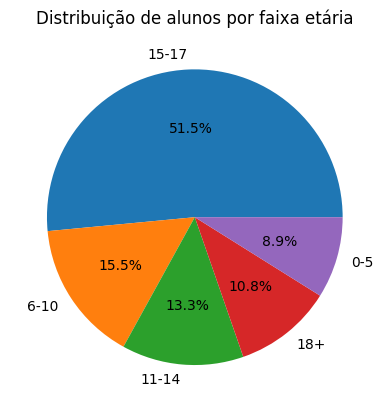

In [165]:
df_aluno_list = df_aluno["faixa_etaria"].value_counts(sort=True)
plt.figure()
plt.pie(
    df_aluno_list["count"],
    labels=df_aluno_list["faixa_etaria"],
    autopct="%1.1f%%",
)
plt.title("Distribuição de alunos por faixa etária")
plt.show()

### Bairro
Considerando que existem x bairros cadastrados, decidi exibir os 10 bairros com o maior número de alunos

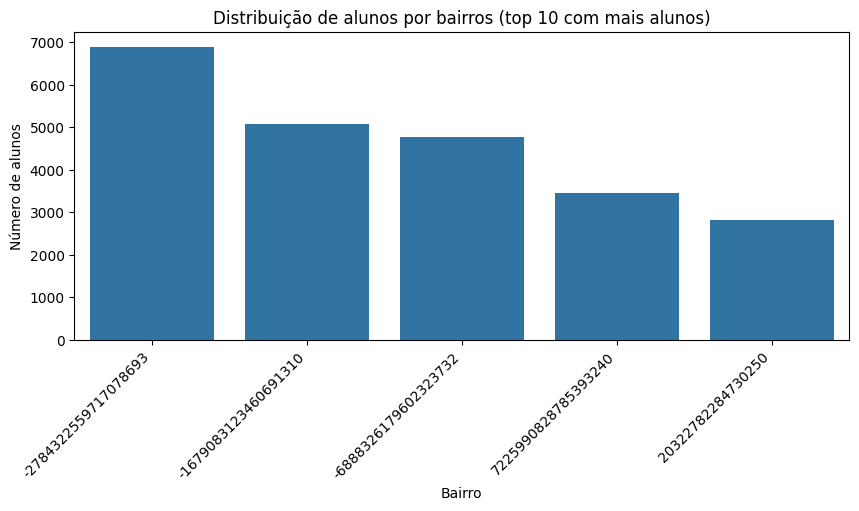

In [162]:
df_aluno_list = df_aluno["bairro"].value_counts(sort=True).head(5)
plt.figure(figsize=(10, 4))
sns.barplot(
    x=df_aluno_list["bairro"],
    y=df_aluno_list["count"],
    order=df_aluno_list["bairro"],
)
plt.title("Distribuição de alunos por bairros (top 10 com mais alunos)")
plt.xlabel("Bairro")
plt.ylabel("Número de alunos")
plt.xticks(rotation=45, ha="right")
plt.show()